# Imports

In [32]:
# Dataset import
from ucimlrepo import fetch_ucirepo

# General imports
import numpy as np
import pandas as pd 

# Visualization imports
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller
from typing import Union
from tqdm import tqdm_notebook
from tqdm.notebook import tqdm

from statsmodels.tsa.statespace.sarimax import SARIMAX
import pandas as pd
from sklearn.metrics import mean_absolute_percentage_error

from sklearn.metrics import mean_absolute_error, root_mean_squared_error

# Load data


In [33]:
# fetch dataset 
bike_sharing = fetch_ucirepo(id=275) 
  
# original df 
df_original = bike_sharing.data.original

# Comprobamos que están todas
X = df_original.drop(["cnt","casual","registered"], axis = "columns")

y_casual = df_original["casual"]
y_registered = df_original["registered"]


# variable information 
print(bike_sharing.variables)

print(df_original.head())


          name     role         type demographic  \
0      instant       ID      Integer        None   
1       dteday  Feature         Date        None   
2       season  Feature  Categorical        None   
3           yr  Feature  Categorical        None   
4         mnth  Feature  Categorical        None   
5           hr  Feature  Categorical        None   
6      holiday  Feature       Binary        None   
7      weekday  Feature  Categorical        None   
8   workingday  Feature       Binary        None   
9   weathersit  Feature  Categorical        None   
10        temp  Feature   Continuous        None   
11       atemp  Feature   Continuous        None   
12         hum  Feature   Continuous        None   
13   windspeed  Feature   Continuous        None   
14      casual    Other      Integer        None   
15  registered    Other      Integer        None   
16         cnt   Target      Integer        None   

                                          description units mis

# Train test split


In [34]:
# 1. Definir dónde damos el "hachazo" (Punto de corte). 
# Por ejemplo, usar el 80% de los datos históricos para entrenar y guardar el 20% final para test.
split_index = int(len(df_original) * 0.80)

y_casual_train = y_casual.iloc[:split_index]
y_casual_test  = y_casual.iloc[split_index:]
y_registered_train = y_registered.iloc[:split_index]
y_registered_test  = y_registered.iloc[split_index:]

# As we know from the delivery1, the time series has a seasonality of 24, so we will apply a seasonal differentiation
# Casual
y_casual_diff = y_casual.diff(periods=24).dropna()
y_casual_train_diff = y_casual_diff.iloc[:split_index - 24]
y_casual_test_diff  = y_casual_diff.iloc[split_index - 24:]

# Registered
y_registered_diff = y_registered.diff(periods=24).dropna()
y_registered_train_diff = y_registered_diff.iloc[:split_index - 24]
y_registered_test_diff  = y_registered_diff.iloc[split_index - 24:]


print(f"Tamaño de entrenamiento casual: {len(y_casual_train_diff)} horas")
print(f"Tamaño de entrenamiento casual: {len(y_casual_test_diff)} horas")

print(f"Tamaño de test registered: {len(y_registered_train_diff)} horas")
print(f"Tamaño de test registered: {len(y_registered_test_diff)} horas")



Tamaño de entrenamiento casual: 13879 horas
Tamaño de entrenamiento casual: 3476 horas
Tamaño de test registered: 13879 horas
Tamaño de test registered: 3476 horas


# Arma - strict ARMA can not be applied


# Arima

## Stationarity


In [35]:
def adf_test(y):
    ADF_result = adfuller(y)
    print(f'ADF Statistic: {ADF_result[0]}')
    print(f'p-value: {ADF_result[1]}') #if <0.05 stationary
    print(ADF_result)

In [36]:
print("ADF CASUAL TEST..............")
adf_test(y_casual_train_diff)

print("\nADF REGISTERED TEST..............")
adf_test(y_registered_train_diff)

ADF CASUAL TEST..............
ADF Statistic: -21.319497578112145
p-value: 0.0
(-21.319497578112145, 0.0, 42, 13836, {'1%': -3.430822717087803, '5%': -2.8617489192123777, '10%': -2.566881202878079}, 116045.32569198495)

ADF REGISTERED TEST..............
ADF Statistic: -18.370012708084765
p-value: 2.2190786059794385e-30
(-18.370012708084765, 2.2190786059794385e-30, 41, 13837, {'1%': -3.430822682918198, '5%': -2.8617489041121855, '10%': -2.566881194840387}, 148780.25454003888)


## Casual user

### AIC


In [37]:


def optimize_ARMA(endog: Union[pd.Series, list], order_list: list) -> pd.DataFrame:
    results = []
    for order in tqdm_notebook(order_list):
      try:
          model = SARIMAX(endog, order=(order[0], 0, order[1]), simple_differencing=False).fit(disp=False)
      except:
        continue
      aic = model.aic
      results.append([order, aic])
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q)', 'AIC']
    #Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC',ascending=True).reset_index(drop=True)
    return result_df

In [38]:
from itertools import product

ps = range(0, 4, 1)
qs = range(0, 4, 1)
order_list = list(product(ps, qs))
result_df = optimize_ARMA(y_casual_train_diff, order_list)
result_df

C:\Users\david.r\AppData\Local\Temp\ipykernel_10652\1985595395.py:3: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for order in tqdm_notebook(order_list):


  0%|          | 0/16 [00:00<?, ?it/s]

c:\Users\david.r\AppData\Local\anaconda3\envs\ML_petfinder\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\david.r\AppData\Local\anaconda3\envs\ML_petfinder\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\david.r\AppData\Local\anaconda3\envs\ML_petfinder\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\david.r\AppData\Local\anaconda3\envs\

,"(p,q)",AIC
0,"(3, 3)",119189.490937
1,"(3, 2)",119460.446176
2,"(2, 3)",119463.826528
3,"(2, 2)",119472.341761
4,"(3, 1)",119527.926776
5,"(1, 3)",119553.802321
6,"(1, 2)",119678.845853
7,"(3, 0)",119708.561615
8,"(2, 1)",119835.359621
9,"(2, 0)",119884.977558


### Residual Analysis

c:\Users\david.r\AppData\Local\anaconda3\envs\ML_petfinder\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\david.r\AppData\Local\anaconda3\envs\ML_petfinder\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\david.r\AppData\Local\anaconda3\envs\ML_petfinder\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



--- Ljung-Box Test (Casual) ---
H0: Residuals are white noise (independent).
If p-value > 0.05, the model is GOOD (no patterns remain).


,lb_stat,lb_pvalue
24,2479.728113,0.0


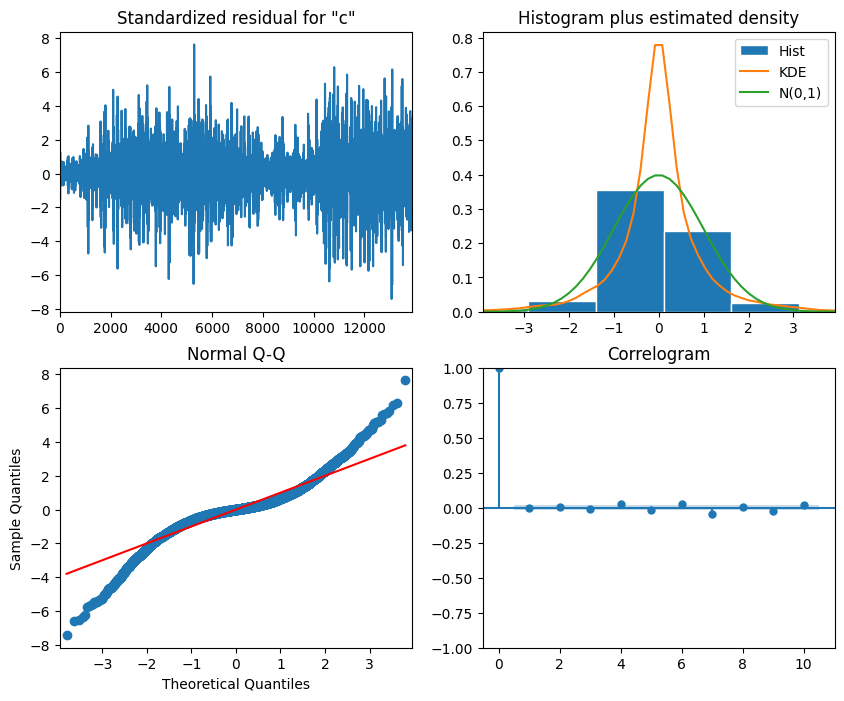

In [39]:
from statsmodels.stats.diagnostic import acorr_ljungbox


model = SARIMAX(y_casual_train_diff, order=(3,0,3),simple_differencing=False)
model_fit = model.fit(disp=False)
model_fit.plot_diagnostics(figsize=(10, 8));
# dropna() is important because when applying D=1 we lose the first 24 residuals
lb_test_casual = acorr_ljungbox(model_fit.resid.dropna(), lags=[24])
print("\n--- Ljung-Box Test (Casual) ---")
print("H0: Residuals are white noise (independent).")
print("If p-value > 0.05, the model is GOOD (no patterns remain).")
display(lb_test_casual)

### Log transformation to try to improve the residuals


In [40]:

# Log + Diff
y_casual_log = np.log1p(y_casual)
y_casual_log_diff = y_casual_log.diff(periods=24).dropna().reset_index(drop=True)
y_casual_train_log_diff = y_casual_log_diff.iloc[:split_index - 24]
y_casual_test_log_diff  = y_casual_log_diff.iloc[split_index - 24:]

In [41]:

ps = range(0, 4, 1)
qs = range(0, 4, 1)
order_list = list(product(ps, qs))
result_df = optimize_ARMA(y_casual_train_log_diff, order_list)
result_df

C:\Users\david.r\AppData\Local\Temp\ipykernel_10652\1985595395.py:3: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for order in tqdm_notebook(order_list):


  0%|          | 0/16 [00:00<?, ?it/s]

c:\Users\david.r\AppData\Local\anaconda3\envs\ML_petfinder\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\david.r\AppData\Local\anaconda3\envs\ML_petfinder\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\david.r\AppData\Local\anaconda3\envs\ML_petfinder\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\david.r\AppData\Local\anaconda3\envs\ML_petfinder\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA pa

,"(p,q)",AIC
0,"(3, 2)",29115.184718
1,"(3, 3)",29193.669686
2,"(2, 3)",29229.656796
3,"(3, 1)",29236.487364
4,"(1, 3)",29260.685317
5,"(2, 1)",29262.750730
6,"(1, 2)",29262.979537
7,"(1, 1)",29262.981350
8,"(2, 2)",29264.547936
9,"(3, 0)",29265.412416


c:\Users\david.r\AppData\Local\anaconda3\envs\ML_petfinder\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\david.r\AppData\Local\anaconda3\envs\ML_petfinder\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'
c:\Users\david.r\AppData\Local\anaconda3\envs\ML_petfinder\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "



--- Ljung-Box Test (Casual) ---
H0: Residuals are white noise (independent).
If p-value > 0.05, the model is GOOD (no patterns remain).


,lb_stat,lb_pvalue
24,2679.550717,0.0


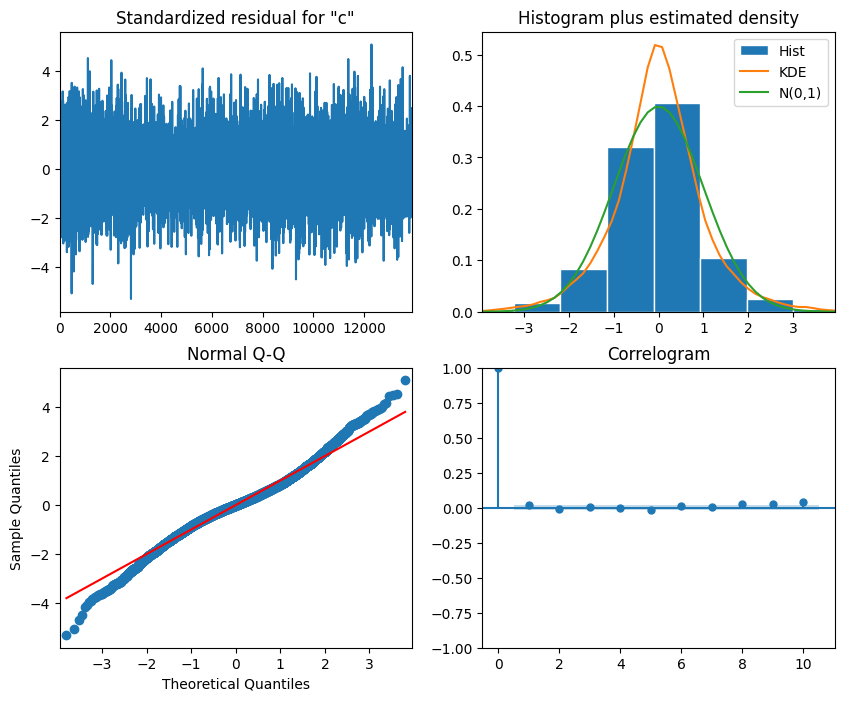

In [42]:

model = SARIMAX(y_casual_train_log_diff, order=(3,0,2),simple_differencing=False)
model_fit = model.fit(disp=False)
model_fit.plot_diagnostics(figsize=(10, 8));


# 4. Quantitative Diagnosis (Ljung-Box Test)
# We look up to lag 24 because that is our daily cycle
residuals_casual = model_fit.resid

# dropna() is important because when applying D=1 we lose the first 24 residuals
lb_test_casual = acorr_ljungbox(residuals_casual.dropna(), lags=[24])
print("\n--- Ljung-Box Test (Casual) ---")
print("H0: Residuals are white noise (independent).")
print("If p-value > 0.05, the model is GOOD (no patterns remain).")
display(lb_test_casual)


With the log transformed target we achieve much better results

### Store the model

In [61]:
model_fit.save('../models/arima_casual_model.pkl')

### Forecasting and Performance Analysis


In [43]:
# =====================================================================
# 2. WALK-FORWARD VALIDATION
# =====================================================================
predictions_log_diff = []
current_res = model_fit
step_size = 24
test_length = len(y_casual_test_log_diff)

for i in tqdm(range(0, test_length, step_size), desc="Días simulados"):
    current_step = min(step_size, test_length - i)
    pred_log_diff = current_res.forecast(steps=current_step)
    predictions_log_diff.extend(pred_log_diff)

    actual_chunk = y_casual_test_log_diff.iloc[i : i + current_step]
    current_res = current_res.append(actual_chunk, refit=False)  

# =====================================================================
# 3. REVERSIÓN — Volver al mundo real
# =====================================================================
casual_pred_series_log_diff = pd.Series(
    predictions_log_diff,
    index=y_casual_test.index  
)

past_log_values = y_casual_log.shift(24).loc[casual_pred_series_log_diff.index]
casual_pred_series_log  = casual_pred_series_log_diff + past_log_values
casual_pred_series_real = np.expm1(casual_pred_series_log)




Días simulados:   0%|          | 0/145 [00:00<?, ?it/s]

In [44]:
y_true = y_casual_test
y_pred = casual_pred_series_real

# 1. MAE (Mean Absolute Error) - Muy fácil de explicar al negocio
mae_casual = mean_absolute_error(y_true, y_pred)
print(f"MAE: {mae_casual:.2f} bicicletas de error en promedio por hora")


# 3. WMAPE (Weighted Mean Absolute Percentage Error) - El mejor para sustituir al MAPE
wmape_casual = np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)
print(f"WMAPE: {wmape_casual * 100:.2f}%")

print(f"Accuracy: {100-wmape_casual*100:.2f}%")


MAE: 19.81 bicicletas de error en promedio por hora
WMAPE: 46.90%
Accuracy: 53.10%


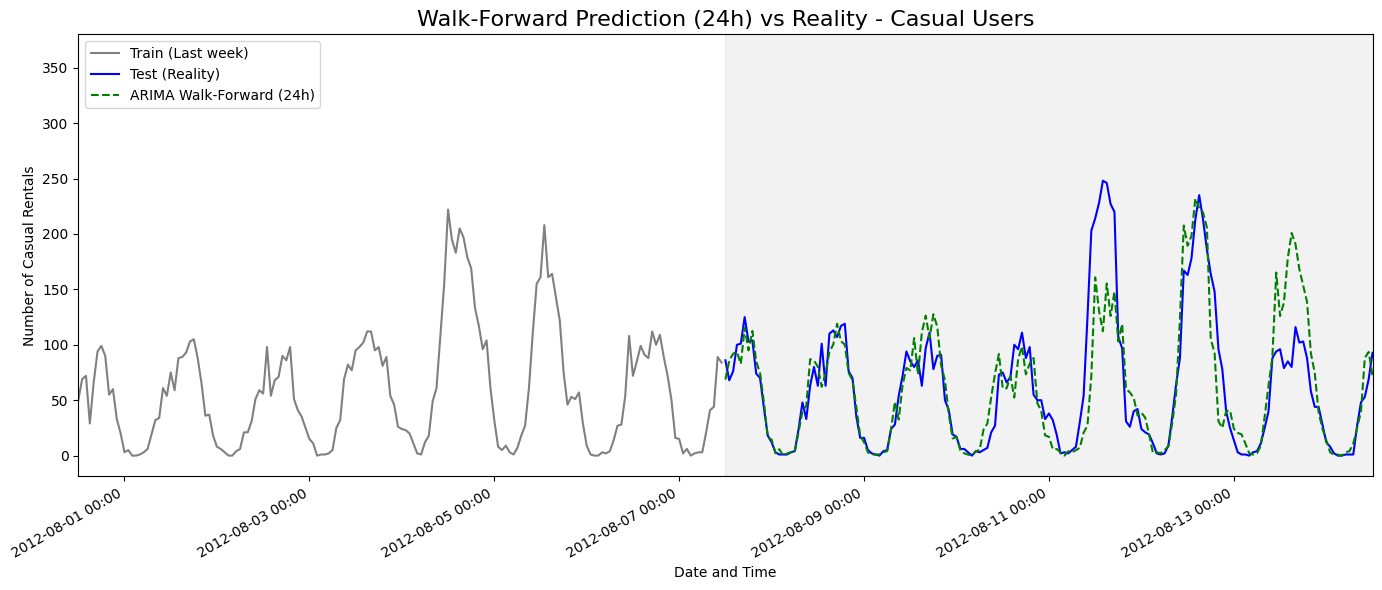

In [45]:
import matplotlib.dates as mdates
import pandas as pd

# =====================================================================
# 2.5 ARREGLAR LOS ÍNDICES (Convertirlos a Fecha y Hora real)
# =====================================================================
# Unimos la columna del día ('dteday') con la columna de la hora ('hr')
fechas_completas = pd.to_datetime(df_original['dteday']) + pd.to_timedelta(df_original['hr'], unit='h')

# Le pegamos estas fechas reales a nuestras 3 variables usando sus índices numéricos actuales
y_casual_train.index = fechas_completas.loc[y_casual_train.index]
y_casual_test.index = fechas_completas.loc[y_casual_test.index]
casual_pred_series_real.index = fechas_completas.loc[casual_pred_series_real.index]


# =====================================================================
# 3. VISUALIZATION (Qualitative)
# =====================================================================
fig, ax = plt.subplots(figsize=(14, 6))

# Contexto: Última semana del Train
ax.plot(y_casual_train.index[-168:], y_casual_train.iloc[-168:], label='Train (Last week)', color='gray')

# Realidad: El Test Set
ax.plot(y_casual_test.index, y_casual_test, label='Test (Reality)', color='blue')

# Predicción: Nuestra serie construida bloque a bloque de 24h
ax.plot(y_casual_test.index, casual_pred_series_real, label='ARIMA Walk-Forward (24h)', color='green', linestyle='--')

# Sombreado del Test Set
ax.axvspan(y_casual_test.index[0], y_casual_test.index[-1], color='#808080', alpha=0.1)

ax.set_title('Walk-Forward Prediction (24h) vs Reality - Casual Users', fontsize=16)
ax.set_xlabel('Date and Time')
ax.set_ylabel('Number of Casual Rentals')
ax.legend(loc='upper left')

# CRITICAL ZOOM: Mantenemos el límite para ver el detalle de los cortes diarios
ax.set_xlim(y_casual_train.index[-168], y_casual_test.index[168]) 

# =====================================================================
# FORMATO DEL EJE X
# =====================================================================
# Ahora sí, usamos la librería de Matplotlib correctamente
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
fig.autofmt_xdate() # Rota las fechas ligeramente para que se lean bien

plt.tight_layout()
plt.show()

## Registered user

### AIC


In [46]:
from typing import Union
from tqdm import tqdm_notebook
from statsmodels.tsa.statespace.sarimax import SARIMAX
import pandas as pd

def optimize_ARMA(endog: Union[pd.Series, list], order_list: list) -> pd.DataFrame:
    results = []
    for order in tqdm_notebook(order_list):
      try:
          model = SARIMAX(endog, order=(order[0], 0, order[1]), simple_differencing=False).fit(disp=False)
      except:
        continue
      aic = model.aic
      results.append([order, aic])
    result_df = pd.DataFrame(results)
    result_df.columns = ['(p,q)', 'AIC']
    #Sort in ascending order, lower AIC is better
    result_df = result_df.sort_values(by='AIC',ascending=True).reset_index(drop=True)
    return result_df

In [47]:
from itertools import product

ps = range(0, 4, 1)
qs = range(0, 4, 1)
order_list = list(product(ps, qs))
result_df = optimize_ARMA(y_registered_train_diff, order_list)
result_df

C:\Users\david.r\AppData\Local\Temp\ipykernel_10652\1047722000.py:8: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for order in tqdm_notebook(order_list):


  0%|          | 0/16 [00:00<?, ?it/s]

c:\Users\david.r\AppData\Local\anaconda3\envs\ML_petfinder\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\david.r\AppData\Local\anaconda3\envs\ML_petfinder\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\david.r\AppData\Local\anaconda3\envs\ML_petfinder\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\david.r\AppData\Local\anaconda3\envs\

,"(p,q)",AIC
0,"(3, 3)",151919.377396
1,"(2, 2)",151923.352529
2,"(2, 3)",151924.351376
3,"(2, 1)",151962.320304
4,"(3, 1)",151963.006675
5,"(3, 2)",151966.240460
6,"(3, 0)",151971.815346
7,"(1, 3)",151973.553092
8,"(1, 2)",151975.355976
9,"(0, 3)",152000.015917


### Residual Analysis

c:\Users\david.r\AppData\Local\anaconda3\envs\ML_petfinder\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\david.r\AppData\Local\anaconda3\envs\ML_petfinder\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
c:\Users\david.r\AppData\Local\anaconda3\envs\ML_petfinder\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\david.r\AppData\Local\anaconda3\envs\ML_petfinder\Lib\site-packages\st


--- Ljung-Box Test (Casual) ---
H0: Residuals are white noise (independent).
If p-value > 0.05, the model is GOOD (no patterns remain).


,lb_stat,lb_pvalue
24,1894.887941,0.0


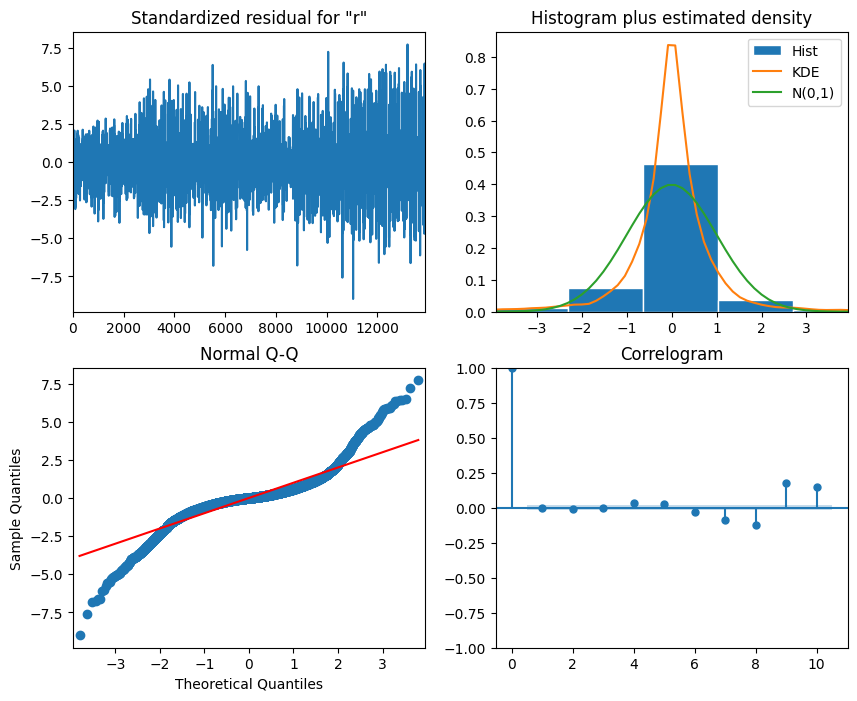

In [48]:
model = SARIMAX(y_registered_train_diff, order=(3,0,3),simple_differencing=False)
model_fit = model.fit(disp=False)
model_fit.plot_diagnostics(figsize=(10, 8));

# 4. Quantitative Diagnosis (Ljung-Box Test)
# We look up to lag 24 because that is our daily cycle
residuals_reg = model_fit.resid

# dropna() is important because when applying D=1 we lose the first 24 residuals
lb_test_reg = acorr_ljungbox(residuals_reg.dropna(), lags=[24])
print("\n--- Ljung-Box Test (Casual) ---")
print("H0: Residuals are white noise (independent).")
print("If p-value > 0.05, the model is GOOD (no patterns remain).")
display(lb_test_reg)


### Log transformation to try to improve the residuals


In [49]:
# Log + Diff
y_registered_log = np.log1p(y_registered)
y_registered_log_diff = y_registered_log.diff(periods=24).dropna().reset_index(drop=True)
y_registered_train_log_diff = y_registered_log_diff.iloc[:split_index - 24]
y_registered_test_log_diff  = y_registered_log_diff.iloc[split_index - 24:]


In [50]:

ps = range(0, 4, 1)
qs = range(0, 4, 1)
order_list = list(product(ps, qs))
result_df = optimize_ARMA(y_registered_train_log_diff, order_list)
result_df

C:\Users\david.r\AppData\Local\Temp\ipykernel_10652\1047722000.py:8: TqdmDeprecationWarning: This function will be removed in tqdm==5.0.0
Please use `tqdm.notebook.tqdm` instead of `tqdm.tqdm_notebook`
  for order in tqdm_notebook(order_list):


  0%|          | 0/16 [00:00<?, ?it/s]

c:\Users\david.r\AppData\Local\anaconda3\envs\ML_petfinder\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\david.r\AppData\Local\anaconda3\envs\ML_petfinder\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


,"(p,q)",AIC
0,"(2, 2)",19929.612450
1,"(3, 2)",19931.601772
2,"(2, 3)",19931.606039
3,"(3, 3)",19933.343699
4,"(3, 1)",19942.928764
5,"(3, 0)",19996.790638
6,"(2, 1)",20113.715896
7,"(1, 3)",20253.156117
8,"(1, 2)",20451.203928
9,"(0, 3)",20475.806846



--- Ljung-Box Test (Casual) ---
H0: Residuals are white noise (independent).
If p-value > 0.05, the model is GOOD (no patterns remain).


,lb_stat,lb_pvalue
24,1893.918697,0.0


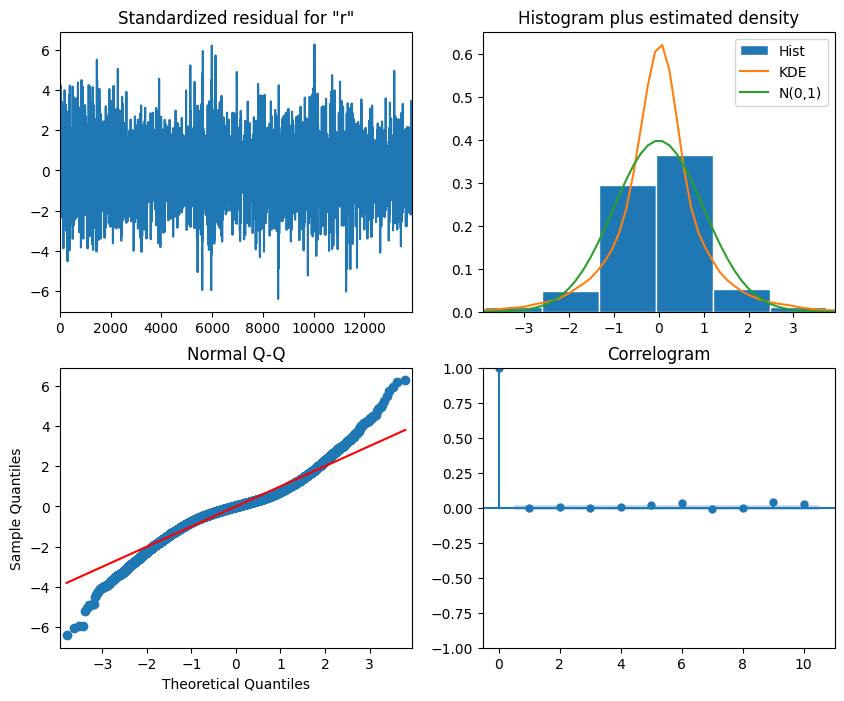

In [51]:

model = SARIMAX(y_registered_train_log_diff, order=(2,0,2),simple_differencing=False)
model_fit = model.fit(disp=False)
model_fit.plot_diagnostics(figsize=(10, 8));


# 4. Quantitative Diagnosis (Ljung-Box Test)
# We look up to lag 24 because that is our daily cycle
residuals_reg = model_fit.resid

# dropna() is important because when applying D=1 we lose the first 24 residuals
lb_test_reg = acorr_ljungbox(residuals_reg.dropna(), lags=[24])
print("\n--- Ljung-Box Test (Casual) ---")
print("H0: Residuals are white noise (independent).")
print("If p-value > 0.05, the model is GOOD (no patterns remain).")
display(lb_test_reg)


### Store the model

In [ ]:
model_fit.save('../models/arima_registered_model.pkl')

### Forecasting and Performance Analysis


In [52]:
# =====================================================================
# 2. WALK-FORWARD VALIDATION
# =====================================================================
predictions_log_diff = []
current_res = model_fit
step_size = 24
test_length = len(y_registered_test_log_diff)

for i in tqdm(range(0, test_length, step_size), desc="Días simulados"):
    current_step = min(step_size, test_length - i)
    pred_log_diff = current_res.forecast(steps=current_step)
    predictions_log_diff.extend(pred_log_diff)

    actual_chunk = y_registered_test_log_diff.iloc[i : i + current_step]
    current_res = current_res.append(actual_chunk, refit=False)  

# =====================================================================
# 3. REVERSIÓN — Volver al mundo real
# =====================================================================
registered_pred_series_log_diff = pd.Series(
    predictions_log_diff,
    index=y_registered_test.index  
)

past_log_values = y_registered_log.shift(24).loc[registered_pred_series_log_diff.index]
registered_pred_series_log  = registered_pred_series_log_diff + past_log_values
registered_pred_series_real = np.expm1(registered_pred_series_log)



Días simulados:   0%|          | 0/145 [00:00<?, ?it/s]

In [53]:
y_true = y_registered_test
y_pred = registered_pred_series_real

# 1. MAE (Mean Absolute Error) - Muy fácil de explicar al negocio
mae_casual = mean_absolute_error(y_true, y_pred)
print(f"MAE: {mae_casual:.2f} bicicletas de error en promedio por hora")


# 3. WMAPE (Weighted Mean Absolute Percentage Error) - El mejor para sustituir al MAPE
wmape_casual = np.sum(np.abs(y_true - y_pred)) / np.sum(y_true)
print(f"WMAPE: {wmape_casual * 100:.2f}%")

print(f"Accuracy: {100-wmape_casual*100:.2f}%")


MAE: 63.69 bicicletas de error en promedio por hora
WMAPE: 30.84%
Accuracy: 69.16%


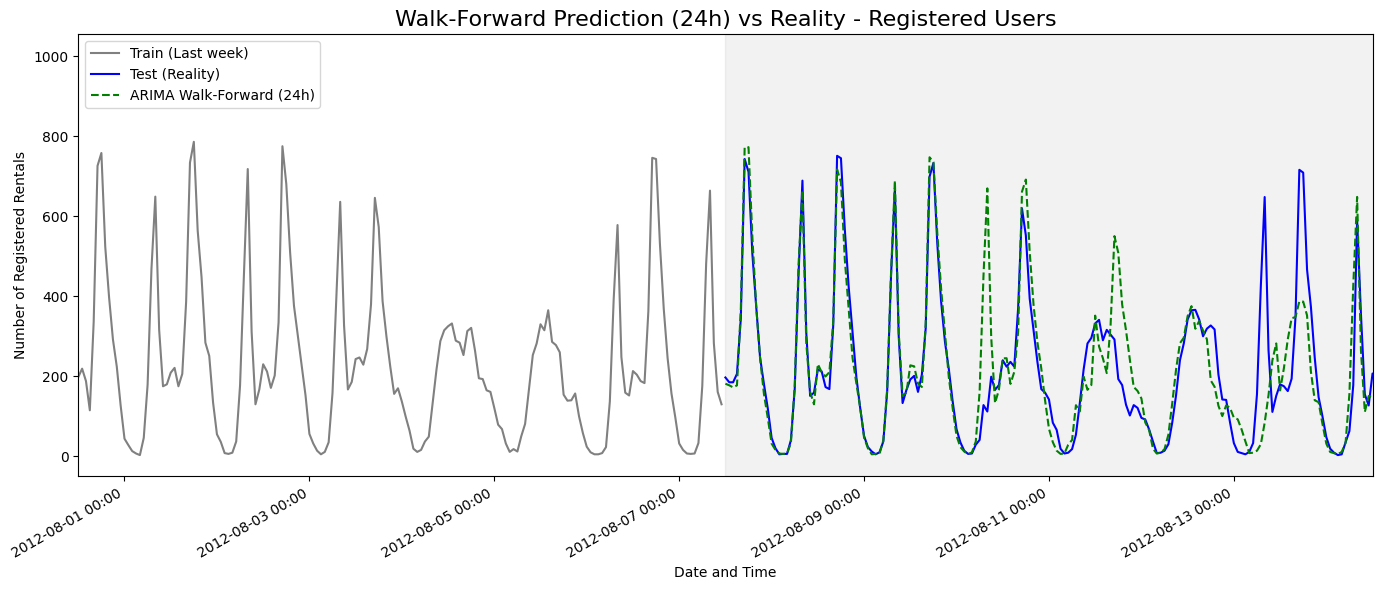

In [54]:
import matplotlib.dates as mdates
import pandas as pd

# =====================================================================
# 2.5 ARREGLAR LOS ÍNDICES (Convertirlos a Fecha y Hora real)
# =====================================================================
# Unimos la columna del día ('dteday') con la columna de la hora ('hr')
fechas_completas = pd.to_datetime(df_original['dteday']) + pd.to_timedelta(df_original['hr'], unit='h')

# Le pegamos estas fechas reales a nuestras 3 variables usando sus índices numéricos actuales
y_registered_train.index = fechas_completas.loc[y_registered_train.index]
y_registered_test.index = fechas_completas.loc[y_registered_test.index]
registered_pred_series_real.index = fechas_completas.loc[registered_pred_series_real.index]


# =====================================================================
# 3. VISUALIZATION (Qualitative)
# =====================================================================
fig, ax = plt.subplots(figsize=(14, 6))

# Contexto: Última semana del Train
ax.plot(y_registered_train.index[-168:], y_registered_train.iloc[-168:], label='Train (Last week)', color='gray')

# Realidad: El Test Set
ax.plot(y_registered_test.index, y_registered_test, label='Test (Reality)', color='blue')

# Predicción: Nuestra serie construida bloque a bloque de 24h
ax.plot(y_registered_test.index, registered_pred_series_real, label='ARIMA Walk-Forward (24h)', color='green', linestyle='--')

# Sombreado del Test Set
ax.axvspan(y_registered_test.index[0], y_registered_test.index[-1], color='#808080', alpha=0.1)

ax.set_title('Walk-Forward Prediction (24h) vs Reality - Registered Users', fontsize=16)
ax.set_xlabel('Date and Time')
ax.set_ylabel('Number of Registered Rentals')
ax.legend(loc='upper left')

# CRITICAL ZOOM: Mantenemos el límite para ver el detalle de los cortes diarios
ax.set_xlim(y_registered_train.index[-168], y_registered_test.index[168]) 

# =====================================================================
# FORMATO DEL EJE X
# =====================================================================
# Ahora sí, usamos la librería de Matplotlib correctamente
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
fig.autofmt_xdate() # Rota las fechas ligeramente para que se lean bien

plt.tight_layout()
plt.show()

## Combined Casual and Registered results with Arima

In [55]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

# =====================================================================
# 1. CREAR LA SERIE GLOBAL (Predicción y Realidad)
# =====================================================================
# Sumamos las predicciones FINALES (las que ya pasaron por np.expm1)
# Asegúrate de que las variables se llaman así en tu código
total_pred_series = casual_pred_series_real + registered_pred_series_real

# Sumamos la realidad del Test Set (que es exactamente igual a la columna 'cnt' original)
y_total_test = y_casual_test + y_registered_test



In [56]:


# =====================================================================
# 2. CALCULAR MÉTRICAS GLOBALES (El rendimiento real del sistema)
# =====================================================================
mae_total = mean_absolute_error(y_total_test, total_pred_series)
wmape_total = np.sum(np.abs(y_total_test - total_pred_series)) / np.sum(y_total_test)

print("--- RENDIMIENTO GLOBAL (Casual + Registered) ---")
print(f"MAE Global:   {mae_total:.2f} bicicletas de error por hora")
print(f"WMAPE Global: {wmape_total * 100:.2f}%")
print(f"Forecast Accuracy: {100 - (wmape_total * 100):.2f}%")

--- RENDIMIENTO GLOBAL (Casual + Registered) ---
MAE Global:   74.61 bicicletas de error por hora
WMAPE Global: 29.99%
Forecast Accuracy: 70.01%


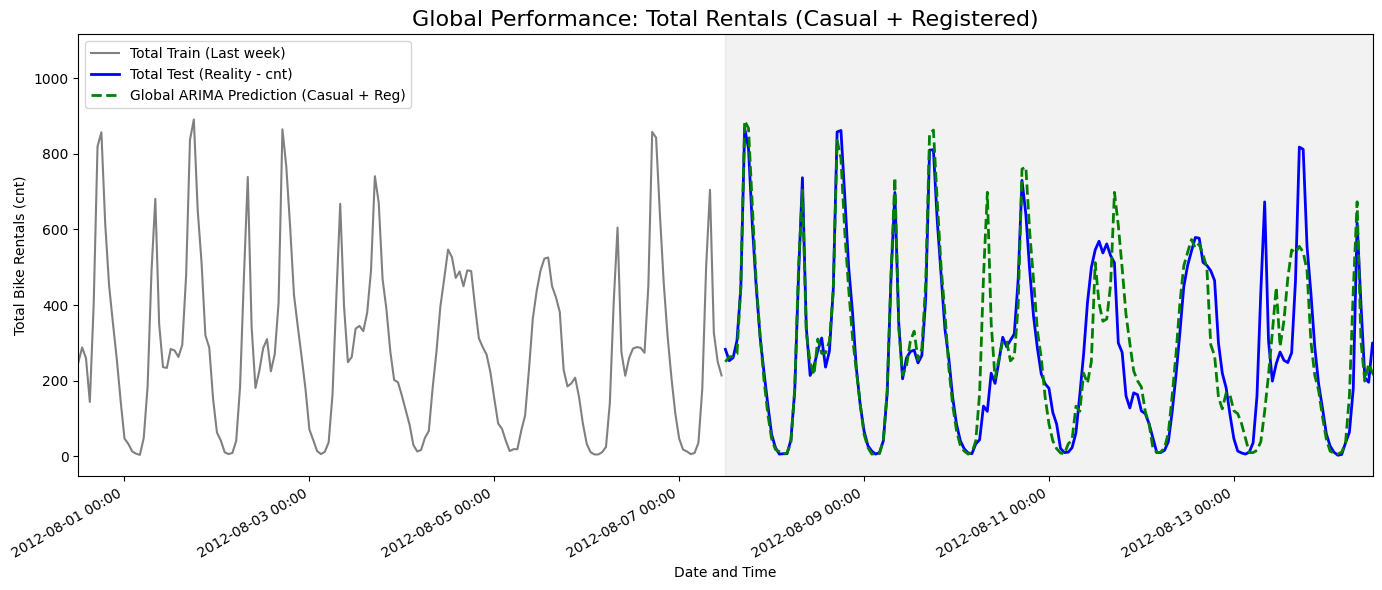

In [57]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# =====================================================================
# 3. VISUALIZACIÓN GLOBAL (Total Rentals)
# =====================================================================
# Reconstruimos el histórico del Train sumando ambos
y_total_train = y_casual_train + y_registered_train

fig, ax = plt.subplots(figsize=(14, 6))

# Histórico Total (Última semana del Train)
ax.plot(y_total_train.index[-168:], y_total_train.iloc[-168:], 
        label='Total Train (Last week)', color='gray')

# Realidad Total (Test Set -> 'cnt')
ax.plot(y_total_test.index, y_total_test, 
        label='Total Test (Reality - cnt)', color='blue', linewidth=2)

# Predicción Total (La suma de tus 2 modelos SARIMA)
ax.plot(total_pred_series.index, total_pred_series, 
        label='Global ARIMA Prediction (Casual + Reg)', color='green', linestyle='--', linewidth=2)

# Sombreado de la zona de Test
ax.axvspan(y_total_test.index[0], y_total_test.index[-1], color='#808080', alpha=0.1)

ax.set_title('Global Performance: Total Rentals (Casual + Registered)', fontsize=16)
ax.set_xlabel('Date and Time')
ax.set_ylabel('Total Bike Rentals (cnt)')
ax.legend(loc='upper left')

# Zoom para ver el detalle (1 semana antes, 1 semana de test)
ax.set_xlim(y_total_train.index[-168], y_total_test.index[168]) 

# Formateo de fechas
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d %H:%M'))
fig.autofmt_xdate()

plt.tight_layout()
plt.show()